In [68]:
import pandas as pd
import numpy as np

import seaborn as sns
sns.set_theme(palette="colorblind")

# Load data

Description of variables: https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset

In [69]:
df = pd.read_csv("https://raw.githubusercontent.com/skforecast/skforecast-datasets/main/data/bike_sharing_dataset_clean.csv", 
                 parse_dates=["date_time"], index_col="date_time")
df = df.asfreq('h')
df = df.drop(columns=["weather", "atemp"])
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 17544 entries, 2011-01-01 00:00:00 to 2012-12-31 23:00:00
Freq: h
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   holiday     17544 non-null  float64
 1   workingday  17544 non-null  float64
 2   temp        17544 non-null  float64
 3   hum         17544 non-null  float64
 4   windspeed   17544 non-null  float64
 5   users       17544 non-null  float64
 6   month       17544 non-null  int64  
 7   hour        17544 non-null  int64  
 8   weekday     17544 non-null  int64  
dtypes: float64(6), int64(3)
memory usage: 1.3 MB


In [70]:
df.head()

,holiday,workingday,temp,hum,windspeed,users,month,hour,weekday
date_time,,,,,,,,,
2011-01-01 00:00:00,0.0,0.0,9.84,81.0,0.0,16.0,1,0,5
2011-01-01 01:00:00,0.0,0.0,9.02,80.0,0.0,40.0,1,1,5
2011-01-01 02:00:00,0.0,0.0,9.02,80.0,0.0,32.0,1,2,5
2011-01-01 03:00:00,0.0,0.0,9.84,75.0,0.0,13.0,1,3,5
2011-01-01 04:00:00,0.0,0.0,9.84,75.0,0.0,1.0,1,4,5


# Train-test split

In [71]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(df, test_size=0.2, random_state=7, shuffle=False)

In [72]:
train_set.shape, test_set.shape

((14035, 9), (3509, 9))

# EDA

<Axes: xlabel='date_time'>

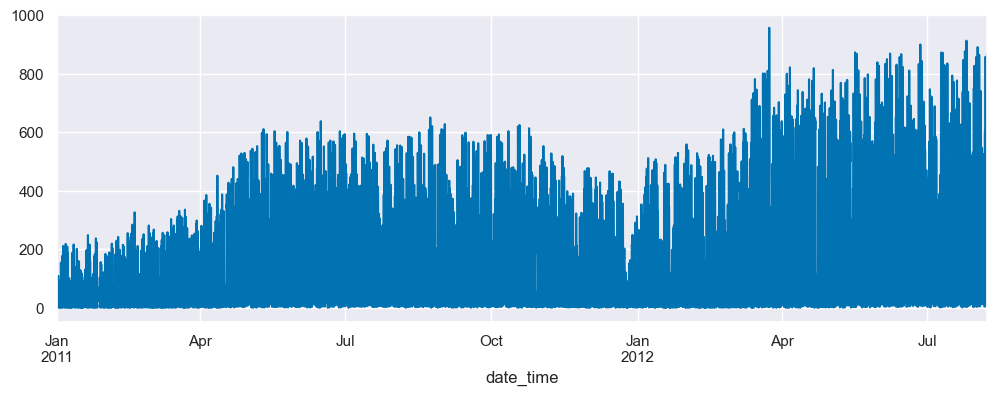

In [73]:
train_set["users"].plot(figsize=(12, 4))

## Zoom in on a month

<Axes: xlabel='date_time'>

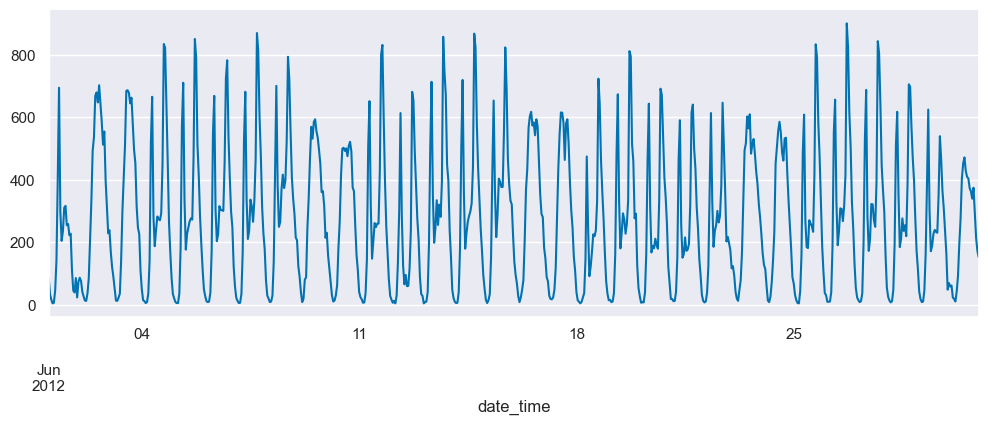

In [74]:
train_set[(train_set.index >= '2012-06-01') & (train_set.index < '2012-07-01')]["users"].plot(figsize=(12, 4))

# Set up TimeSeriesFold

In [117]:
from skforecast.model_selection import TimeSeriesFold
from sklearn.metrics import root_mean_squared_error


cv = TimeSeriesFold(
         steps=24, # =forecast horizon
         initial_train_size=train_set.shape[0], # size of the initial training set
         refit=False, # if true, the forecaster is refitted at each fold
         fixed_train_size=False # fixed-size or expanding training data
     )

# Baseline

In [118]:
from skforecast.recursive import ForecasterEquivalentDate
from skforecast.model_selection._validation import backtesting_forecaster


last_value_forecaster = ForecasterEquivalentDate(offset=1, n_offsets=1)

results_lv, predictions_backtest = backtesting_forecaster(
                                   forecaster=last_value_forecaster,
                                   y=df['users'],
                                   cv=cv,
                                   metric=[root_mean_squared_error, 
                                           'mean_absolute_error'],
                                   n_jobs='auto',
                                   verbose=False,
                                   show_progress=True
                               )
results_lv.index = ["Last-Value"]

  0%|          | 0/147 [00:00<?, ?it/s]

In [119]:
results_lv

,root_mean_squared_error,mean_absolute_error
Last-Value,412.611249,336.979196


# Model development

## Hyperparameter optimisation

In [120]:
from sklearn.ensemble import RandomForestRegressor
from skforecast.recursive import ForecasterRecursive
from skforecast.model_selection import grid_search_forecaster

import warnings
from skforecast.exceptions import IgnoredArgumentWarning
warnings.simplefilter('ignore', category=IgnoredArgumentWarning)


forecaster = ForecasterRecursive(
    estimator=RandomForestRegressor(),
    lags=24
)

# Lags grid
lags_grid = [6, 12, 24]

# Hyperparameter search space
hp_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
}

# list of exog features
exog_features = train_set.columns.to_list()
exog_features.remove("users")

cv_hp_search = TimeSeriesFold(
    steps=24, # =forecast horizon
    initial_train_size=int(len(train_set) * 0.8), # 80% training, 20% validation
    refit=False, # if true, the forecaster is refitted at each fold
    fixed_train_size=False # fixed-size or expanding training data
)

results_search = grid_search_forecaster(
    forecaster=forecaster,
    y=train_set["users"],
    exog=train_set[exog_features],  
    cv=cv_hp_search,
    param_grid=hp_grid,
    lags_grid=lags_grid,
    metric='mean_absolute_error',
    return_best=True
)

lags grid:   0%|          | 0/3 [00:00<?, ?it/s]

params grid:   0%|          | 0/24 [00:00<?, ?it/s]

params grid:   0%|          | 0/24 [00:00<?, ?it/s]

c:\Users\pekarv\AppData\Local\anaconda3\Lib\site-packages\skforecast\model_selection\_search.py:481: RuntimeWarning: Parameters skipped: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}. Could not pickle the task to send it to the workers.
  warnings.warn(f"Parameters skipped: {params}. {e}", RuntimeWarning)


params grid:   0%|          | 0/24 [00:00<?, ?it/s]

c:\Users\pekarv\AppData\Local\anaconda3\Lib\site-packages\skforecast\model_selection\_search.py:481: RuntimeWarning: Parameters skipped: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}. Could not pickle the task to send it to the workers.
  warnings.warn(f"Parameters skipped: {params}. {e}", RuntimeWarning)
c:\Users\pekarv\AppData\Local\anaconda3\Lib\site-packages\skforecast\model_selection\_search.py:481: RuntimeWarning: Parameters skipped: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}. A task has failed to un-serialize. Please ensure that the arguments of the function are all picklable.
  warnings.warn(f"Parameters skipped: {params}. {e}", RuntimeWarning)
c:\Users\pekarv\AppData\Local\anaconda3\Lib\site-packages\skforecast\model_selection\_search.py:481: RuntimeWarning: Parameters skipped: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}. A task has failed to un-serialize. Please ensure that the arguments of the function are all pic

In [122]:
results_search.head(3)

,lags,lags_label,params,mean_absolute_error,max_depth,min_samples_split,n_estimators
0,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 10, 'min_samples_split': 2, 'n_e...",72.337684,10.0,2.0,100.0
1,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 10, 'min_samples_split': 5, 'n_e...",73.672254,10.0,5.0,100.0
2,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14...","{'max_depth': 10, 'min_samples_split': 2, 'n_e...",74.158310,10.0,2.0,200.0


In [123]:
best_params = results_search['params'].iat[0]
best_params

{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}

In [124]:
best_lags = results_search['lags'].iat[0]
best_lags

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24])

## Evaluate the best model on test set

In [135]:
results_rf, predictions = backtesting_forecaster(
                        forecaster=forecaster, # use the forecaster with the best HPs found in the search
                        y=df['users'],
                        exog=df[exog_features],
                        cv=cv,
                        metric=[root_mean_squared_error, 
                                 'mean_absolute_error'],
                     )
results_rf.index = ["Random Forest"]
results_rf

  0%|          | 0/147 [00:00<?, ?it/s]

,root_mean_squared_error,mean_absolute_error
Random Forest,99.327667,58.241913


## Plot predictions

<Axes: >

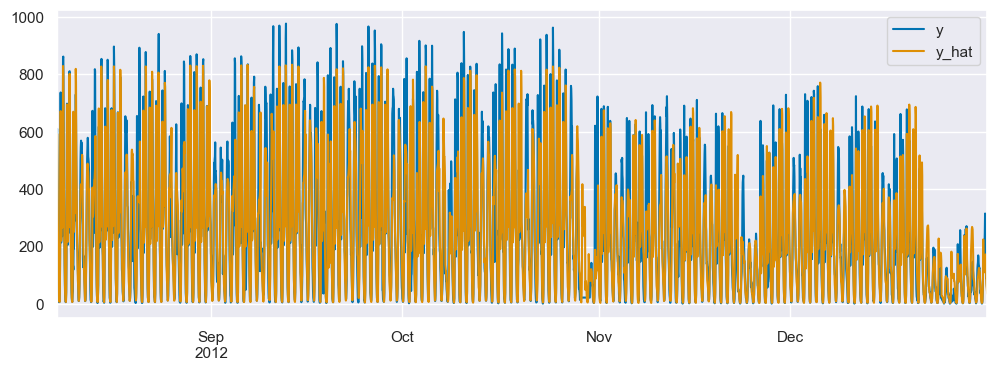

In [126]:
tdf = pd.DataFrame({"y": test_set['users'], "y_hat": predictions['pred']})
tdf.plot(figsize=(12,4))

## Feature Selection

In [ ]:
from skforecast.feature_selection import select_features
from sklearn.feature_selection import RFECV

rf = RandomForestRegressor(**best_params)
selector = RFECV(estimator=rf, step=1, cv=3)

selected_lags, selected_window_features, selected_exog = select_features(
    forecaster=forecaster,
    selector=selector, # or, SelectKBest(f_regression, k=5)
    y=train_set['users'],  
    exog=train_set[exog_features],
    subsample=1.0, 
    random_state=7,
    verbose=True
)

Recursive feature elimination (RFECV)
-------------------------------------
Total number of records available: 14011
Total number of records used for feature selection: 14011
Number of features available: 32
    Lags            (n=24)
    Window features (n=0)
    Exog            (n=8)
Number of features selected: 31
    Lags            (n=24) : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
    Window features (n=0) : []
    Exog            (n=7) : ['workingday', 'temp', 'hum', 'windspeed', 'month', 'hour', 'weekday']


## Re-run backtesting on selected features

In [133]:
forecaster = ForecasterRecursive(
    estimator=RandomForestRegressor(**best_params),
    lags=selected_lags
)

results_rf_fs, predictions = backtesting_forecaster(
                        forecaster=forecaster, 
                        y=df['users'],
                        exog=df[selected_exog],
                        cv=cv,
                        metric=[root_mean_squared_error, 
                                 'mean_absolute_error'],
                        n_jobs=1,
                     )
results_rf_fs.index = ["Random Forest (feature selection)"]
results_rf_fs

  0%|          | 0/147 [00:00<?, ?it/s]

,root_mean_squared_error,mean_absolute_error
Random Forest (feature selection),98.854704,57.826344


# Summary table

In [136]:
tdf = pd.concat([results_lv, results_rf, results_rf_fs], axis=0)
tdf

,root_mean_squared_error,mean_absolute_error
Last-Value,412.611249,336.979196
Random Forest,99.327667,58.241913
Random Forest (feature selection),98.854704,57.826344


## Feature importances

### Model-specific scores

In [95]:
forecaster.fit(y=train_set['users'], exog=train_set[exog_features])
importances = forecaster.get_feature_importances()
importances

,feature,importance
0,lag_1,0.717952
4,lag_24,0.123171
11,hour,0.081166
3,lag_23,0.033930
1,lag_9,0.025951
6,workingday,0.005004
12,weekday,0.003989
2,lag_14,0.003898
7,temp,0.002350
10,month,0.001192


### SHAP

In [96]:
import shap

X_train, y_train = forecaster.create_train_X_y(
    y=train_set['users'], exog=train_set[exog_features])

explainer = shap.TreeExplainer(forecaster.estimator)

shap_values = explainer.shap_values(X_train)

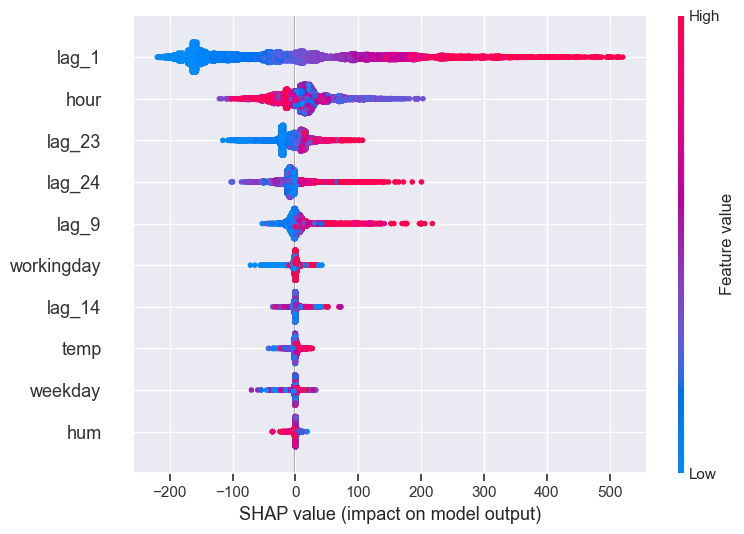

In [97]:
shap.initjs()
shap.summary_plot(shap_values, X_train, max_display=10, show=False)